# Strategic Insights & Recommendations

## Executive Summary

Based on Q4 2020 sales data analysis, this report provides actionable recommendations for AAL's sales and marketing strategy moving into 2021.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../AusApparalSales4thQrt2020.csv')

for col in ['Time', 'State', 'Group']:
    df[col] = df[col].str.strip()

total_revenue = df['Sales'].sum()
state_revenue = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

## Key Findings

### 1. Market Concentration
Revenue is concentrated in a handful of states. Let's examine the distribution.

In [2]:
revenue_pct = (state_revenue / total_revenue * 100).round(1)

print("Q4 2020 Revenue Distribution:\n")
for state, pct in revenue_pct.items():
    print(f"{state}: {pct}%")

top_3_pct = revenue_pct.head(3).sum()
print(f"\nTop 3 States: {top_3_pct}% of total revenue")
print(f"Other States: {100 - top_3_pct}% of total revenue")

Q4 2020 Revenue Distribution:

VIC: 31.0%
NSW: 22.0%
SA: 17.3%
QLD: 9.8%
TAS: 6.7%
NT: 6.6%
WA: 6.5%

Top 3 States: 70.3% of total revenue
Other States: 29.700000000000003% of total revenue


### 2. Demographic Insights

Different states have different customer mixes.

In [9]:
demo_by_state = df.groupby(['State', 'Group'])['Sales'].sum().unstack(fill_value=0)
demo_pct = demo_by_state.div(demo_by_state.sum(axis=1), axis=0) * 100

print("Customer Segment Performance by State (% of State Revenue):\n")
print(demo_pct.round(1))

overall_demo = df.groupby('Group')['Sales'].sum()
print(f"\nOverall Top Customer Group: {overall_demo.idxmax()} (${overall_demo.max():,.0f})")

for state in state_revenue.index:
    top_segment = demo_by_state.loc[state].idxmax()
    revenue = demo_by_state.loc[state, top_segment]
    pct = demo_pct.loc[state, top_segment]
    print(f"{state}: {top_segment} ({pct:.0f}% - ${revenue:,.0f})")

Customer Segment Performance by State (% of State Revenue):

Group  Kids   Men  Seniors  Women
State                            
NSW    24.8  25.4     24.3   25.6
NT     25.2  25.5     24.2   25.0
QLD    25.5  25.1     24.5   24.9
SA     24.7  24.9     25.0   25.4
TAS    25.4  25.3     24.8   24.5
VIC    25.0  25.0     24.9   25.1
WA     25.4  26.0     24.9   23.8

Overall Top Customer Group: Men ($85,750,000)
VIC: Women (25% - $26,482,500)
NSW: Women (26% - $19,172,500)
SA: Women (25% - $14,970,000)
QLD: Kids (25% - $8,510,000)
TAS: Kids (25% - $5,775,000)
NT: Men (26% - $5,762,500)
WA: Men (26% - $5,752,500)


### 3. Time Period Opportunity

Are there untapped opportunities in specific time periods?

In [4]:
time_performance = df.groupby(['State', 'Time'])['Sales'].sum().unstack(fill_value=0)
time_pct = time_performance.div(time_performance.sum(axis=1), axis=0) * 100

print("Time Period Performance by State (% of State Revenue):\n")
print(time_pct.round(1))

overall_time = df.groupby('Time')['Sales'].sum()
print(f"\nRevenue by Time Period:")
for time, revenue in overall_time.items():
    pct = (revenue / overall_time.sum()) * 100
    print(f"  {time}: ${revenue:,.0f} ({pct:.1f}%)")

Time Period Performance by State (% of State Revenue):

Time   Afternoon  Evening  Morning
State                             
NSW         33.5     33.0     33.5
NT          33.3     33.8     33.0
QLD         34.0     31.8     34.2
SA          34.0     32.9     33.1
TAS         33.7     33.2     33.1
VIC         33.2     33.0     33.7
WA          32.9     33.0     34.2

Revenue by Time Period:
  Afternoon: $114,007,500 (33.5%)
  Evening: $112,087,500 (32.9%)
  Morning: $114,207,500 (33.6%)


## Strategic Recommendations for S&M Leadership

### For High-Performing States (VIC, NSW, SA)

**Maintain Market Position & Optimize**
- Continue current strategies in these mature markets
- Focus on margin improvement and customer retention
- Explore premium product lines targeting high-value segments (Women, Seniors)
- Revenue is fairly evenly split across Morning, Afternoon and Evening here, so there isn't an obvious time-of-day gap to close

### For Growth-Opportunity States (WA, NT, TAS, QLD)

**Targeted Growth Programs**

**Western Australia (WA) and Northern Territory (NT):**
- Smallest markets, both sitting around $22M for the quarter
- Segment mix is close to even across Kids/Men/Women/Seniors, so there's no single underperforming demographic to fix - this points to a market awareness problem rather than a targeting problem
- Test localized marketing and possibly a flagship presence to build brand visibility

**Tasmania (TAS):**
- Similar profile to WA/NT - small but consistent across segments and time periods
- Group with NT/WA for a shared regional growth initiative rather than treating in isolation

**Queensland (QLD):**
- Sits in the middle of the pack, well below VIC/NSW/SA but ahead of WA/NT/TAS
- Worth investigating why it hasn't grown in line with the top 3 states
- Develop state-specific marketing campaigns

### Cross-State Initiatives

1. **Segment-Based Programs**
   - Segment mix (Kids/Men/Women/Seniors) is remarkably consistent across every state, hovering around 24-26% each - this is a stable base to build on rather than a gap to close
   - Men and Women are essentially tied nationally as the top segments; Women lead in the big three states (VIC, NSW, SA) while Men lead in the smaller markets - worth keeping product mix broad rather than over-indexing on one group

2. **Time Period Optimization**
   - Morning, Afternoon and Evening are all within a percentage point of each other nationally - time-of-day isn't the lever to pull here
   - Any staffing/promo decisions should be driven by state-level totals, not time period

3. **Expansion Priority**
   - Group WA, NT and TAS together for a shared regional growth program - they behave almost identically in the data
   - QLD needs its own investigation since it underperforms relative to its size
   - Hold off on new state expansion until the growth-tier states close some of the gap with VIC/NSW/SA

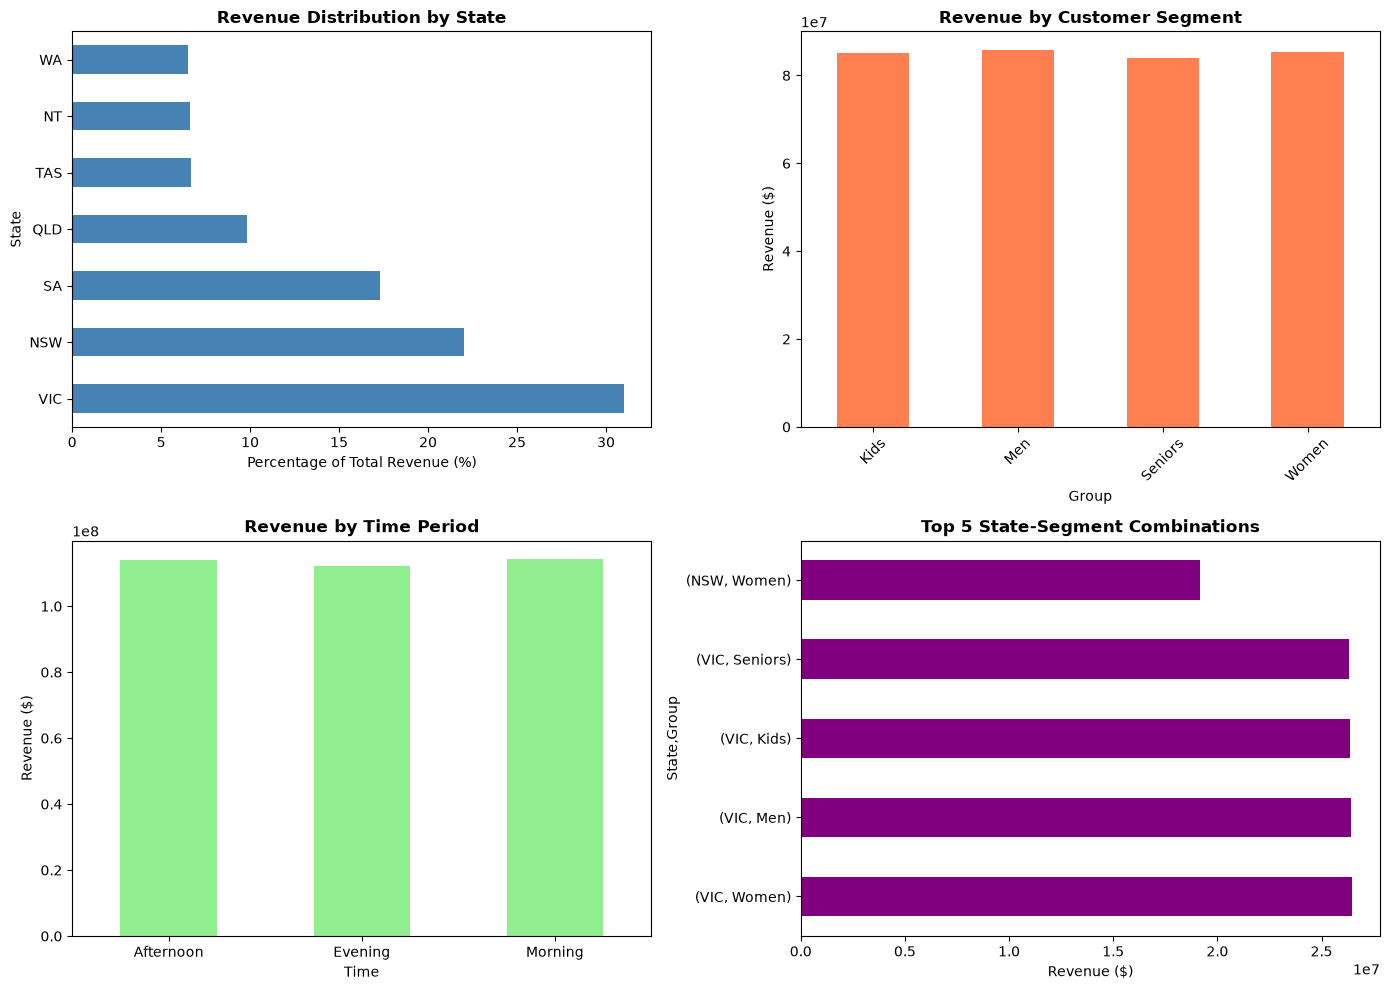

Executive summary visualization saved


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

revenue_pct.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Revenue Distribution by State', fontweight='bold')
axes[0, 0].set_xlabel('Percentage of Total Revenue (%)')

overall_demo.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Revenue by Customer Segment', fontweight='bold')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

overall_time.plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Revenue by Time Period', fontweight='bold')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=0)

top_5_combos = df.groupby(['State', 'Group'])['Sales'].sum().nlargest(5)
top_5_combos.plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Top 5 State-Segment Combinations', fontweight='bold')
axes[1, 1].set_xlabel('Revenue ($)')

plt.tight_layout()
plt.savefig('../outputs/visualizations/executive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("Executive summary visualization saved")

## Next Steps

1. **Q1 2021 Actions**
   - Launch a shared growth program for WA, NT and TAS
   - Investigate QLD's underperformance relative to VIC/NSW/SA
   - Keep segment marketing broad-based since Kids/Men/Women/Seniors are already balanced

2. **Market Research**
   - Investigate QLD underperformance vs. state population
   - Customer awareness surveys in WA/NT/TAS
   - Competitive analysis in growth-opportunity states

3. **Performance Tracking**
   - Monthly state-level dashboards
   - Segment performance by state
   - Revisit this analysis next quarter to see if the gap is closing

4. **Investment Priorities**
   - WA/NT/TAS regional growth push (currently 13% of revenue combined)
   - QLD diagnostic work
   - Maintain current strategy in VIC/NSW/SA